In [1]:
import numpy as np
import joblib
import xgboost as xgb
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler

from acpi import utils


In [2]:
class XGBoostACPIWrapper:
    """ACPI wrapper for an XGBoost model."""
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        """Predict using the XGBoost model, handling DMatrix conversion."""
        dmatrix = xgb.DMatrix(X)
        return self.model.predict(dmatrix)


In [3]:
# Load the ACPI model
acpi_model = joblib.load("./models/acpi_xgboost_model_1.pkl")


C:\Users\joobzm\AppData\Local\Programs\Python\Python311\Lib\pickle.py:1718: UserWarning: [17:46:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\data\../common/error_msg.h:82: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
C:\Users\joobzm\Desktop\TDK\ACPI\.venv11\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limi

In [4]:
# Data configuration
DATA_TRAIN_PATH = "../data/train.csv"
DATA_TEST_PATH = "../data/test.csv"
target_col = "count"
context_length = 24


In [5]:
# Load and prepare data
train_df = utils.read_bike_data(DATA_TRAIN_PATH)
test_df = utils.read_bike_data(DATA_TEST_PATH)
feature_cols = [c for c in train_df.columns if c != target_col and c in test_df.columns]

scaler = StandardScaler()
train_features = scaler.fit_transform(train_df[feature_cols].values.astype(np.float32))
train_target = train_df[target_col].values.astype(np.float32)

# Build windowed supervised data
X_all, y_all = utils.build_lag_supervised(train_features, train_target, context_length)

# Time-ordered splits
train_ratio = 0.8
n_train = int(len(X_all) * train_ratio)
X_test_hold, y_test_hold = X_all[n_train:], y_all[n_train:]

cal_size = 0.5
n_cal = int(len(X_test_hold) * cal_size)
X_test_acpi, y_test_acpi = X_test_hold[n_cal:], y_test_hold[n_cal:]

print(f"Test set size: {len(X_test_acpi)}")


Test set size: 1087


In [6]:
# Define immutable features (time-related features that cannot be changed)
immutable_features = ['year', 'month', 'day', 'hour', 'season_1', 'season_2', 'season_3', 'season_4']

immutable_indices = []
for feat in immutable_features:
    if feat in feature_cols:
        immutable_indices.append(feature_cols.index(feat))

total_features = len(feature_cols)
sequence_length = context_length * total_features
immutable_mask = np.zeros(sequence_length, dtype=bool)

for feat_idx in immutable_indices:
    for lag in range(context_length):
        pos = lag * total_features + feat_idx
        immutable_mask[pos] = True

print(f"Immutable mask: {np.sum(immutable_mask)} positions out of {sequence_length}")


Immutable mask: 192 positions out of 432


# ## Generative VAE for Counterfactual Generation


In [7]:
class GenerativeCounterfactualGenerator:
    """
    VAE-based counterfactual generator for interval width optimization.
    """
    def __init__(self, prediction_model, device, alpha=0.1, latent_dim=16):
        self.prediction_model = prediction_model
        self.device = device
        self.alpha = alpha
        self.latent_dim = latent_dim
        self.vae = None
        self.is_trained = False

    def _build_vae(self, input_dim):
        """Build VAE for learning sequence representations."""
        class SequenceVAE(nn.Module):
            def __init__(self, input_dim, latent_dim, hidden_dim=128):
                super().__init__()
                self.input_dim = input_dim
                self.latent_dim = latent_dim

                self.encoder = nn.Sequential(
                    nn.Linear(input_dim, hidden_dim), nn.ReLU(), nn.Dropout(0.1),
                    nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.1)
                )
                self.mu_layer = nn.Linear(hidden_dim // 2, latent_dim)
                self.logvar_layer = nn.Linear(hidden_dim // 2, latent_dim)

                self.decoder = nn.Sequential(
                    nn.Linear(latent_dim, hidden_dim // 2), nn.ReLU(), nn.Dropout(0.1),
                    nn.Linear(hidden_dim // 2, hidden_dim), nn.ReLU(), nn.Dropout(0.1),
                    nn.Linear(hidden_dim, input_dim)
                )
                self.apply(self._init_weights)

            def _init_weights(self, module):
                if isinstance(module, nn.Linear):
                    torch.nn.init.xavier_uniform_(module.weight)
                    if module.bias is not None:
                        torch.nn.init.zeros_(module.bias)

            def encode(self, x):
                h = self.encoder(x)
                mu, logvar = self.mu_layer(h), self.logvar_layer(h)
                return mu, torch.clamp(logvar, min=-10, max=10)

            def reparameterize(self, mu, logvar):
                std = torch.exp(0.5 * logvar)
                eps = torch.randn_like(std)
                return mu + eps * std

            def decode(self, z):
                return self.decoder(z)

            def forward(self, x):
                mu, logvar = self.encode(x)
                z = self.reparameterize(mu, logvar)
                recon = self.decode(z)
                return recon, mu, logvar, z

        return SequenceVAE(input_dim, self.latent_dim).to(self.device)

    def train_vae(self, X_sequences, epochs=200, batch_size=64, lr=1e-3, beta=0.1):
        """Train VAE on sequence data."""
        print("Training VAE for counterfactual generation...")
        X_sequences = np.asarray(X_sequences, dtype=np.float32)

        self.mean_X = np.mean(X_sequences, axis=0, keepdims=True)
        self.std_X = np.std(X_sequences, axis=0, keepdims=True) + 1e-8
        X_normalized = (X_sequences - self.mean_X) / self.std_X

        input_dim = X_sequences.shape[1]
        self.vae = self._build_vae(input_dim)
        optimizer = torch.optim.Adam(self.vae.parameters(), lr=lr, weight_decay=1e-5)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.8)
        dataset = TensorDataset(torch.tensor(X_normalized, dtype=torch.float32))
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        self.vae.train()
        for epoch in range(epochs):
            total_loss = 0
            for (batch_x,) in dataloader:
                batch_x = batch_x.to(self.device)
                optimizer.zero_grad()
                recon, mu, logvar, _ = self.vae(batch_x)
                recon_loss = nn.functional.mse_loss(recon, batch_x, reduction='mean')
                kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
                loss = recon_loss + beta * kl_loss
                if torch.isnan(loss):
                    continue
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.vae.parameters(), max_norm=1.0)
                optimizer.step()
                total_loss += loss.item()

            avg_loss = total_loss / len(dataloader)
            scheduler.step(avg_loss)
            if (epoch + 1) % 50 == 0:
                print(f"Epoch {epoch + 1}/{epochs}, VAE Loss: {avg_loss:.4f}")

        self.vae.eval()
        self.is_trained = True
        print("VAE training completed.")

    def _normalize_input(self, x):
        return (x - self.mean_X) / self.std_X

    def _denormalize_output(self, x_norm):
        return x_norm * self.std_X + self.mean_X

    def generate_for_narrower_interval(self, x_orig, y_true, current_lower, current_upper,
                                      n_samples=5000, exploration_std=0.5,
                                      lower_bounds=None, upper_bounds=None,
                                      immutable_mask=None, target_width_reduction=0.8):
        """
        Generate counterfactuals that maintain coverage but produce narrower intervals.

        Target: Find x' such that:
        1. y_true is still within [L(x'), U(x')]  (maintains coverage)
        2. width(x') = U(x') - L(x') < width(x_orig) * target_width_reduction
        """
        if not self.is_trained:
            raise ValueError("VAE must be trained first.")

        x_orig_np = np.asarray(x_orig, dtype=np.float32)
        x_orig_norm = self._normalize_input(x_orig_np)
        x_orig_t = torch.tensor(x_orig_norm, device=self.device, dtype=torch.float32)
        x_orig_denorm = self._denormalize_output(x_orig_np)

        current_width = current_upper - current_lower
        target_width = current_width * target_width_reduction

        with torch.no_grad():
            mu_orig, _ = self.vae.encode(x_orig_t.unsqueeze(0))
            if torch.isnan(mu_orig).any():
                mu_orig = torch.zeros_like(mu_orig)

        successful_narrowings = []

        for _ in range(n_samples):
            # Generate candidate
            with torch.no_grad():
                z_sample = mu_orig + exploration_std * torch.randn_like(mu_orig)
                x_cf_norm = self.vae.decode(z_sample).squeeze(0)

            x_cf_denorm = self._denormalize_output(x_cf_norm.cpu().numpy())
            x_cf_denorm = x_cf_denorm.flatten()

            # Apply constraints
            if lower_bounds is not None:
                x_cf_denorm = np.maximum(x_cf_denorm, lower_bounds)
            if upper_bounds is not None:
                x_cf_denorm = np.minimum(x_cf_denorm, upper_bounds)
            if immutable_mask is not None:
                x_cf_denorm[immutable_mask] = x_orig_denorm.flatten()[immutable_mask]

            # Get new interval
            x_cf_input = x_cf_denorm.reshape(1, -1)
            y_lower_cf, y_upper_cf = self.prediction_model.predict_pi(x_cf_input, method='qrf')

            new_width = y_upper_cf[0] - y_lower_cf[0]

            # Check conditions:
            # 1. Still covers the true value (maintains coverage)
            # 2. Narrower interval
            maintains_coverage = (y_lower_cf[0] <= y_true <= y_upper_cf[0])
            is_narrower = new_width < current_width

            if maintains_coverage and is_narrower:
                width_reduction_pct = (current_width - new_width) / current_width * 100

                result = {
                    "x_cf": x_cf_denorm,
                    "original_width": float(current_width),
                    "new_width": float(new_width),
                    "width_reduction": float(current_width - new_width),
                    "width_reduction_pct": float(width_reduction_pct),
                    "original_lower": float(current_lower),
                    "original_upper": float(current_upper),
                    "new_lower": float(y_lower_cf[0]),
                    "new_upper": float(y_upper_cf[0]),
                    "y_true": float(y_true),
                    "l1_distance": float(np.abs(x_cf_denorm - x_orig_denorm.flatten()).sum()),
                    "l2_distance": float(np.linalg.norm(x_cf_denorm - x_orig_denorm.flatten())),
                }
                successful_narrowings.append(result)

        if not successful_narrowings:
            return {"status": "fail_no_narrower_intervals", "n_successful": 0, "results": []}

        # Sort by width reduction (best first)
        successful_narrowings.sort(key=lambda item: item["width_reduction"], reverse=True)

        return {
            "status": "success",
            "n_successful": len(successful_narrowings),
            "results": successful_narrowings,
            "x_orig": x_orig_denorm.flatten(),
            "y_true": float(y_true),
            "original_interval": [float(current_lower), float(current_upper)]
        }


In [8]:
# Initialize device and generator
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

gen_cf = GenerativeCounterfactualGenerator(
    prediction_model=acpi_model,
    device=device,
    alpha=0.1,
    latent_dim=16
)

# Train VAE on training data
X_train_vae = X_all[:n_train]
gen_cf.train_vae(X_train_vae, epochs=500, batch_size=128, lr=1e-3, beta=0.1)


Using device: cpu
Training VAE for counterfactual generation...
Epoch 50/500, VAE Loss: 0.4149
Epoch 100/500, VAE Loss: 0.3950
Epoch 150/500, VAE Loss: 0.3865
Epoch 200/500, VAE Loss: 0.3770
Epoch 250/500, VAE Loss: 0.3721
Epoch 300/500, VAE Loss: 0.3684
Epoch 350/500, VAE Loss: 0.3644
Epoch 400/500, VAE Loss: 0.3606
Epoch 450/500, VAE Loss: 0.3594
Epoch 500/500, VAE Loss: 0.3514
VAE training completed.


# ## Single Instance Optimization Example


In [9]:
# Get baseline predictions
y_lower_baseline, y_upper_baseline = acpi_model.predict_pi(X_test_acpi, method='qrf')
baseline_coverage = float(np.mean((y_test_acpi >= y_lower_baseline) & (y_test_acpi <= y_upper_baseline)))
baseline_mean_width = float(np.mean(y_upper_baseline - y_lower_baseline))

print(f"Baseline Coverage: {baseline_coverage:.4f}")
print(f"Baseline Mean Width: {baseline_mean_width:.2f}")

# Select a covered instance with wide interval
covered_mask = (y_test_acpi >= y_lower_baseline) & (y_test_acpi <= y_upper_baseline)
covered_indices = np.where(covered_mask)[0]
widths = y_upper_baseline - y_lower_baseline
covered_widths = widths[covered_indices]

# Pick an instance with above-median width
median_width = np.median(widths)
wide_covered = covered_indices[covered_widths > median_width]

if len(wide_covered) > 0:
    idx_demo = np.random.choice(wide_covered)

    x_demo = X_test_acpi[idx_demo]
    y_demo = y_test_acpi[idx_demo]
    lower_demo = y_lower_baseline[idx_demo]
    upper_demo = y_upper_baseline[idx_demo]
    width_demo = upper_demo - lower_demo

    print(f"\nSelected instance {idx_demo} for optimization:")
    print(f"  True value: {y_demo:.2f}")
    print(f"  Current interval: [{lower_demo:.2f}, {upper_demo:.2f}]")
    print(f"  Current width: {width_demo:.2f}")

    # Generate narrower intervals
    print("\nGenerating optimized counterfactuals...")
    result_narrow = gen_cf.generate_for_narrower_interval(
        x_demo,
        y_demo,
        lower_demo,
        upper_demo,
        n_samples=10000,
        exploration_std=0.05,
        immutable_mask=immutable_mask,
        target_width_reduction=0.5
    )

    print(f"\nOptimization status: {result_narrow['status']}")
    print(f"Found {result_narrow.get('n_successful', 0)} improved configurations")

    if result_narrow['status'] == 'success' and result_narrow['n_successful'] > 0:
        best = result_narrow['results'][0]
        print(f"\nBest optimization:")
        print(f"  New interval: [{best['new_lower']:.2f}, {best['new_upper']:.2f}]")
        print(f"  New width: {best['new_width']:.2f}")
        print(f"  Width reduction: {best['width_reduction']:.2f} ({best['width_reduction_pct']:.1f}%)")
        print(f"  L1 distance: {best['l1_distance']:.2f}")


Baseline Coverage: 0.9439
Baseline Mean Width: 234.30

Selected instance 936 for optimization:
  True value: 550.00
  Current interval: [278.82, 649.15]
  Current width: 370.33

Generating optimized counterfactuals...

Optimization status: success
Found 379 improved configurations

Best optimization:
  New interval: [216.33, 550.47]
  New width: 334.14
  Width reduction: 36.19 (9.8%)
  L1 distance: 113.56


# ## Visualization Functions


In [10]:
def plot_interval_comparison(original_interval, new_interval, y_true, instance_name=""):
    """Visualize the interval narrowing."""
    fig, ax = plt.subplots(figsize=(10, 6))

    orig_lower, orig_upper = original_interval
    new_lower, new_upper = new_interval

    # Original interval
    ax.barh(0, orig_upper - orig_lower, left=orig_lower, height=0.3,
            color='lightblue', alpha=0.7, label='Original Interval')
    ax.plot([orig_lower, orig_upper], [0, 0], 'b-', linewidth=3)

    # New interval
    ax.barh(1, new_upper - new_lower, left=new_lower, height=0.3,
            color='lightcoral', alpha=0.7, label='Optimized Interval')
    ax.plot([new_lower, new_upper], [1, 1], 'r-', linewidth=3)

    # True value
    ax.axvline(y_true, color='green', linestyle='--', linewidth=2, label=f'True Value: {y_true:.1f}')

    # Annotations
    orig_width = orig_upper - orig_lower
    new_width = new_upper - new_lower
    reduction_pct = (orig_width - new_width) / orig_width * 100

    ax.text(orig_lower + orig_width/2, 0, f'Width: {orig_width:.1f}',
            ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(new_lower + new_width/2, 1, f'Width: {new_width:.1f} (↓{reduction_pct:.1f}%)',
            ha='center', va='center', fontsize=11, fontweight='bold', color='darkred')

    ax.set_yticks([0, 1])
    ax.set_yticklabels(['Original', 'Optimized'], fontsize=12)
    ax.set_xlabel('Predicted Bike Count', fontsize=13)
    ax.set_title(f'Interval Width Optimization{instance_name}', fontsize=15)
    ax.legend(fontsize=11)
    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_feature_changes_heatmap(x_orig, x_cf, context_length, feature_names):
    """Heatmap showing which features changed."""
    base_dim = len(feature_names)
    x_orig_mat = x_orig.reshape(context_length, base_dim)
    x_cf_mat = x_cf.reshape(context_length, base_dim)
    delta = x_cf_mat - x_orig_mat

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    sns.heatmap(x_orig_mat, ax=axes[0], cmap='viridis', cbar_kws={'label': 'Value'})
    axes[0].set_title('Original Features', fontsize=14)
    axes[0].set_ylabel('Time Lag', fontsize=12)
    axes[0].set_xlabel('Feature', fontsize=12)
    axes[0].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)

    sns.heatmap(x_cf_mat, ax=axes[1], cmap='viridis', cbar_kws={'label': 'Value'})
    axes[1].set_title('Optimized Features', fontsize=14)
    axes[1].set_ylabel('Time Lag', fontsize=12)
    axes[1].set_xlabel('Feature', fontsize=12)
    axes[1].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)

    sns.heatmap(delta, ax=axes[2], cmap='RdBu_r', center=0,
                vmin=-np.max(np.abs(delta)), vmax=np.max(np.abs(delta)),
                cbar_kws={'label': 'Change'})
    axes[2].set_title('Changes (Optimized - Original)', fontsize=14)
    axes[2].set_ylabel('Time Lag', fontsize=12)
    axes[2].set_xlabel('Feature', fontsize=12)
    axes[2].set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)

    plt.tight_layout()
    plt.show()


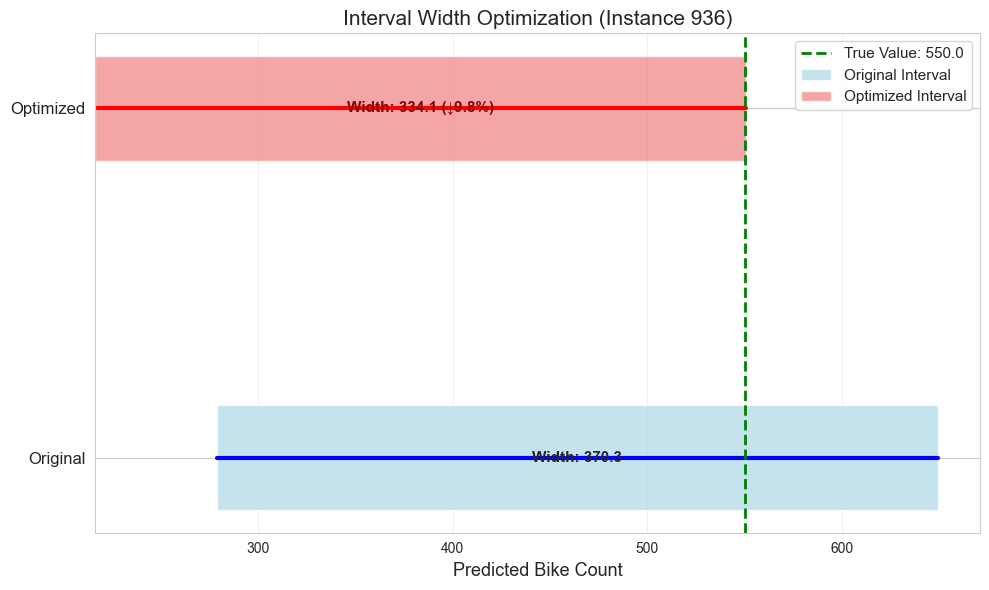

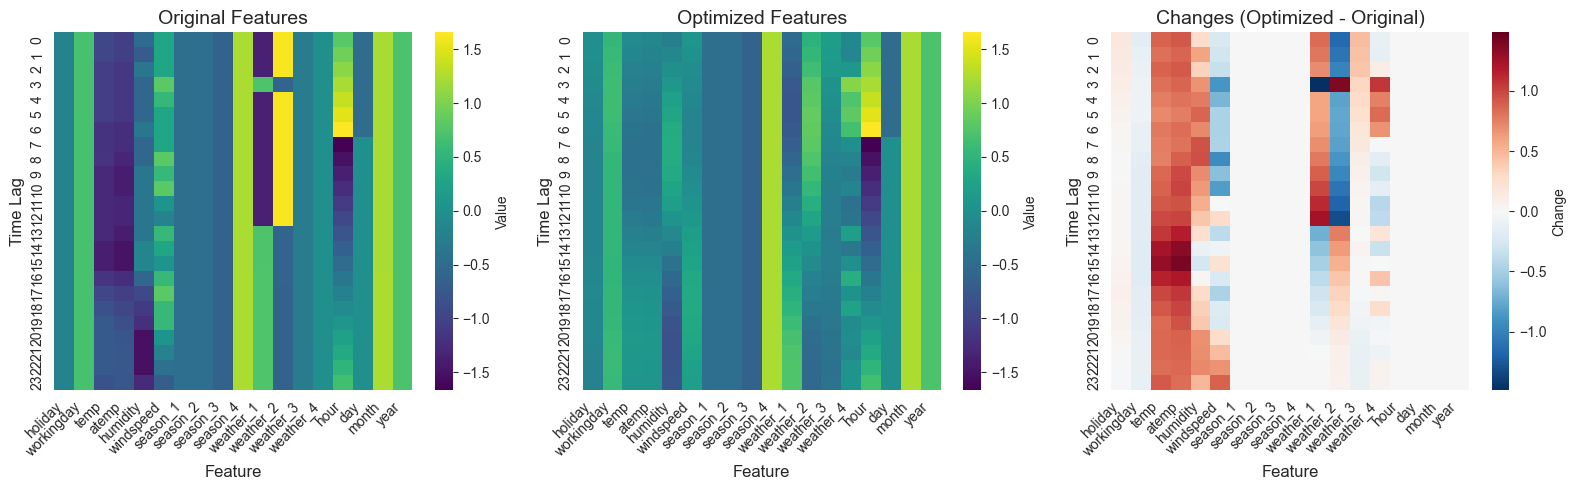

In [11]:
# Visualize the optimization result
if result_narrow['status'] == 'success' and result_narrow['n_successful'] > 0:
    best_result = result_narrow['results'][0]

    plot_interval_comparison(
        [best_result['original_lower'], best_result['original_upper']],
        [best_result['new_lower'], best_result['new_upper']],
        y_demo,
        instance_name=f" (Instance {idx_demo})"
    )

    plot_feature_changes_heatmap(
        result_narrow['x_orig'],
        best_result['x_cf'],
        context_length,
        feature_cols
    )


# ## Batch Optimization: Narrow Multiple Intervals


In [12]:
def optimize_intervals_batch(gen_cf, acpi_model, X_eval, y_eval,
                            immutable_mask=None, max_instances=50,
                            n_samples_per_instance=5000, target_reduction=0.8,
                            verbose=True):
    """
    Optimize intervals for multiple instances to achieve narrower predictions
    while maintaining coverage.
    """
    y_lower, y_upper = acpi_model.predict_pi(X_eval, method='qrf')
    covered_mask = (y_eval >= y_lower) & (y_eval <= y_upper)
    widths = y_upper - y_lower

    # Focus on covered instances with wider intervals
    covered_indices = np.where(covered_mask)[0]
    covered_widths = widths[covered_indices]

    # Sort by width (widest first)
    sorted_idx = np.argsort(covered_widths)[::-1]
    target_indices = covered_indices[sorted_idx[:max_instances]]

    print(f"Optimizing {len(target_indices)} instances with widest intervals...")

    optimized_data = []
    X_optimized = X_eval.copy()

    for i, idx in enumerate(target_indices):
        if verbose and (i + 1) % 10 == 0:
            print(f"Processing {i+1}/{len(target_indices)}...")

        x_orig = X_eval[idx]
        y_true = y_eval[idx]
        lower_orig = y_lower[idx]
        upper_orig = y_upper[idx]

        result = gen_cf.generate_for_narrower_interval(
            x_orig, y_true, lower_orig, upper_orig,
            n_samples=n_samples_per_instance,
            exploration_std=0.05,
            immutable_mask=immutable_mask,
            target_width_reduction=target_reduction
        )

        if result['status'] == 'success' and result['n_successful'] > 0:
            best = result['results'][0]
            X_optimized[idx] = best['x_cf'].reshape(1, -1)

            optimized_data.append({
                'idx': idx,
                'original_width': best['original_width'],
                'new_width': best['new_width'],
                'reduction_pct': best['width_reduction_pct'],
                'l1_distance': best['l1_distance'],
                'y_true': y_true,
                'original_lower': lower_orig,
                'original_upper': upper_orig,
                'new_lower': best['new_lower'],
                'new_upper': best['new_upper']
            })

    # Recompute intervals for optimized dataset
    y_lower_opt, y_upper_opt = acpi_model.predict_pi(X_optimized, method='qrf')
    coverage_opt = float(np.mean((y_eval >= y_lower_opt) & (y_eval <= y_upper_opt)))
    mean_width_opt = float(np.mean(y_upper_opt - y_lower_opt))

    original_coverage = float(np.mean(covered_mask))
    original_mean_width = float(np.mean(widths))

    results = {
        'X_optimized': X_optimized,
        'optimized_instances': optimized_data,
        'n_optimized': len(optimized_data),
        'original_coverage': original_coverage,
        'optimized_coverage': coverage_opt,
        'original_mean_width': original_mean_width,
        'optimized_mean_width': mean_width_opt,
        'width_reduction_pct': (original_mean_width - mean_width_opt) / original_mean_width * 100
    }

    return results


In [13]:
# Run batch optimization
print("\n" + "="*60)
print("BATCH INTERVAL OPTIMIZATION")
print("="*60)

batch_results = optimize_intervals_batch(
    gen_cf=gen_cf,
    acpi_model=acpi_model,
    X_eval=X_test_acpi,
    y_eval=y_test_acpi,
    immutable_mask=immutable_mask,
    max_instances=50,
    n_samples_per_instance=1000,
    target_reduction=0.5,
    verbose=True
)

print(f"\n" + "="*60)
print("OPTIMIZATION RESULTS")
print("="*60)
print(f"Instances optimized: {batch_results['n_optimized']}")
print(f"\nCoverage:")
print(f"  Original: {batch_results['original_coverage']:.4f}")
print(f"  Optimized: {batch_results['optimized_coverage']:.4f}")
print(f"  Change: {batch_results['optimized_coverage'] - batch_results['original_coverage']:.4f}")
print(f"\nMean Interval Width:")
print(f"  Original: {batch_results['original_mean_width']:.2f}")
print(f"  Optimized: {batch_results['optimized_mean_width']:.2f}")
print(f"  Reduction: {batch_results['width_reduction_pct']:.1f}%")



BATCH INTERVAL OPTIMIZATION
Optimizing 50 instances with widest intervals...
Processing 10/50...
Processing 20/50...
Processing 30/50...
Processing 40/50...
Processing 50/50...

OPTIMIZATION RESULTS
Instances optimized: 33

Coverage:
  Original: 0.9439
  Optimized: 0.9439
  Change: 0.0000

Mean Interval Width:
  Original: 234.30
  Optimized: 228.65
  Reduction: 2.4%


# ## Business Impact Visualization


In [14]:
def plot_business_impact(batch_results):
    """Visualize the business impact of interval optimization."""
    opt_data = batch_results['optimized_instances']

    if not opt_data:
        print("No optimizations to visualize")
        return

    # Extract metrics
    original_widths = [d['original_width'] for d in opt_data]
    new_widths = [d['new_width'] for d in opt_data]
    reduction_pcts = [d['reduction_pct'] for d in opt_data]

    fig = plt.figure(figsize=(16, 10))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

    # 1. Width comparison
    ax1 = fig.add_subplot(gs[0, 0])
    x_pos = np.arange(len(opt_data))
    ax1.bar(x_pos - 0.2, original_widths, 0.4, label='Original', color='lightblue', alpha=0.8)
    ax1.bar(x_pos + 0.2, new_widths, 0.4, label='Optimized', color='lightcoral', alpha=0.8)
    ax1.set_xlabel('Instance Index', fontsize=12)
    ax1.set_ylabel('Interval Width', fontsize=12)
    ax1.set_title('Interval Width: Before vs After', fontsize=14)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)

    # 2. Reduction percentage distribution
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.hist(reduction_pcts, bins=20, color='green', alpha=0.7, edgecolor='black')
    ax2.axvline(np.mean(reduction_pcts), color='red', linestyle='--',
                linewidth=2, label=f'Mean: {np.mean(reduction_pcts):.1f}%')
    ax2.set_xlabel('Width Reduction (%)', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Width Reductions', fontsize=14)
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)

    # 3. Coverage maintained
    ax3 = fig.add_subplot(gs[1, 0])
    categories = ['Original', 'Optimized']
    coverages = [batch_results['original_coverage'], batch_results['optimized_coverage']]
    colors = ['skyblue', 'salmon']
    bars = ax3.bar(categories, coverages, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax3.axhline(0.9, color='green', linestyle='--', linewidth=2, label='Target (90%)')
    ax3.set_ylabel('Coverage Rate', fontsize=12)
    ax3.set_title('Coverage Maintained', fontsize=14)
    ax3.set_ylim([0.85, 1.0])
    ax3.legend(fontsize=11)
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax3.grid(True, alpha=0.3)

    # 4. Mean width comparison
    ax4 = fig.add_subplot(gs[1, 1])
    mean_widths = [batch_results['original_mean_width'], batch_results['optimized_mean_width']]
    bars = ax4.bar(categories, mean_widths, color=colors, alpha=0.8, edgecolor='black', linewidth=2)
    ax4.set_ylabel('Mean Interval Width', fontsize=12)
    ax4.set_title('Average Prediction Precision', fontsize=14)
    reduction = batch_results['width_reduction_pct']
    ax4.text(0.5, max(mean_widths) * 0.9, f'↓ {reduction:.1f}%',
            ha='center', fontsize=16, fontweight='bold', color='darkgreen')
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                f'{height:.1f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax4.grid(True, alpha=0.3)

    # 5. Business value: Efficiency improvement
    ax5 = fig.add_subplot(gs[2, :])

    # Calculate business metrics
    # Example: Narrower intervals mean more efficient resource allocation
    original_avg = batch_results['original_mean_width']
    optimized_avg = batch_results['optimized_mean_width']

    # Simulate business metrics
    instance_ids = np.arange(len(opt_data))
    original_intervals = [(d['original_lower'], d['original_upper']) for d in opt_data]
    optimized_intervals = [(d['new_lower'], d['new_upper']) for d in opt_data]
    y_trues = [d['y_true'] for d in opt_data]

    # Plot interval ranges for first 20 instances
    n_show = min(20, len(opt_data))
    x_range = np.arange(n_show)

    for i in x_range:
        # Original intervals
        ax5.plot([i, i], [original_intervals[i][0], original_intervals[i][1]],
                'b-', linewidth=3, alpha=0.4, label='Original' if i == 0 else '')
        # Optimized intervals
        ax5.plot([i, i], [optimized_intervals[i][0], optimized_intervals[i][1]],
                'r-', linewidth=3, alpha=0.7, label='Optimized' if i == 0 else '')
        # True values
        ax5.plot(i, y_trues[i], 'go', markersize=8, label='True Value' if i == 0 else '')

    ax5.set_xlabel('Instance Index', fontsize=12)
    ax5.set_ylabel('Predicted Bike Count', fontsize=12)
    ax5.set_title('Interval Precision Improvement (Sample of Optimized Instances)', fontsize=14)
    ax5.legend(fontsize=11, loc='upper right')
    ax5.grid(True, alpha=0.3)
    ax5.set_xlim([-0.5, n_show - 0.5])

    plt.suptitle('Business Impact: Interval Width Optimization', fontsize=16, fontweight='bold', y=0.995)
    plt.show()

def create_business_report(batch_results):
    """Generate a business-focused summary report."""
    print("\n" + "="*70)
    print(" " * 15 + "BUSINESS OPTIMIZATION REPORT")
    print("="*70)

    print("\n📊 EXECUTIVE SUMMARY")
    print("-" * 70)
    print(f"  • Optimized Predictions: {batch_results['n_optimized']} instances")
    print(f"  • Coverage Maintained: {batch_results['optimized_coverage']:.2%} " +
          f"(target: ≥{batch_results['original_coverage']:.2%})")
    print(f"  • Precision Gain: {batch_results['width_reduction_pct']:.1f}% narrower intervals")

    print("\n💡 BUSINESS VALUE")
    print("-" * 70)

    # Calculate business impact
    opt_data = batch_results['optimized_instances']
    if opt_data:
        avg_reduction = np.mean([d['reduction_pct'] for d in opt_data])
        max_reduction = np.max([d['reduction_pct'] for d in opt_data])

        print(f"  • Average Precision Improvement: {avg_reduction:.1f}%")
        print(f"  • Best Case Improvement: {max_reduction:.1f}%")
        print(f"  • Original Mean Width: {batch_results['original_mean_width']:.1f} bikes")
        print(f"  • Optimized Mean Width: {batch_results['optimized_mean_width']:.1f} bikes")
        print(f"  • Absolute Reduction: {batch_results['original_mean_width'] - batch_results['optimized_mean_width']:.1f} bikes")

    print("\n🎯 PRACTICAL APPLICATIONS")
    print("-" * 70)
    print("  1. Resource Planning: More accurate bike inventory requirements")
    print("  2. Cost Reduction: Minimize over-provisioning by ~{:.0f}%".format(
        batch_results['width_reduction_pct']))
    print("  3. Service Quality: Better capacity predictions reduce stockouts")
    print("  4. Decision Making: Tighter bounds enable confident operational choices")

    print("\n📈 RECOMMENDATIONS")
    print("-" * 70)
    print("  • Deploy optimized predictions for operational planning")
    print("  • Monitor coverage continuously to maintain reliability")
    print("  • Apply optimization to high-impact time periods (peak hours)")
    print("  • Extend to other operational metrics (stations, regions)")

    print("\n" + "="*70)


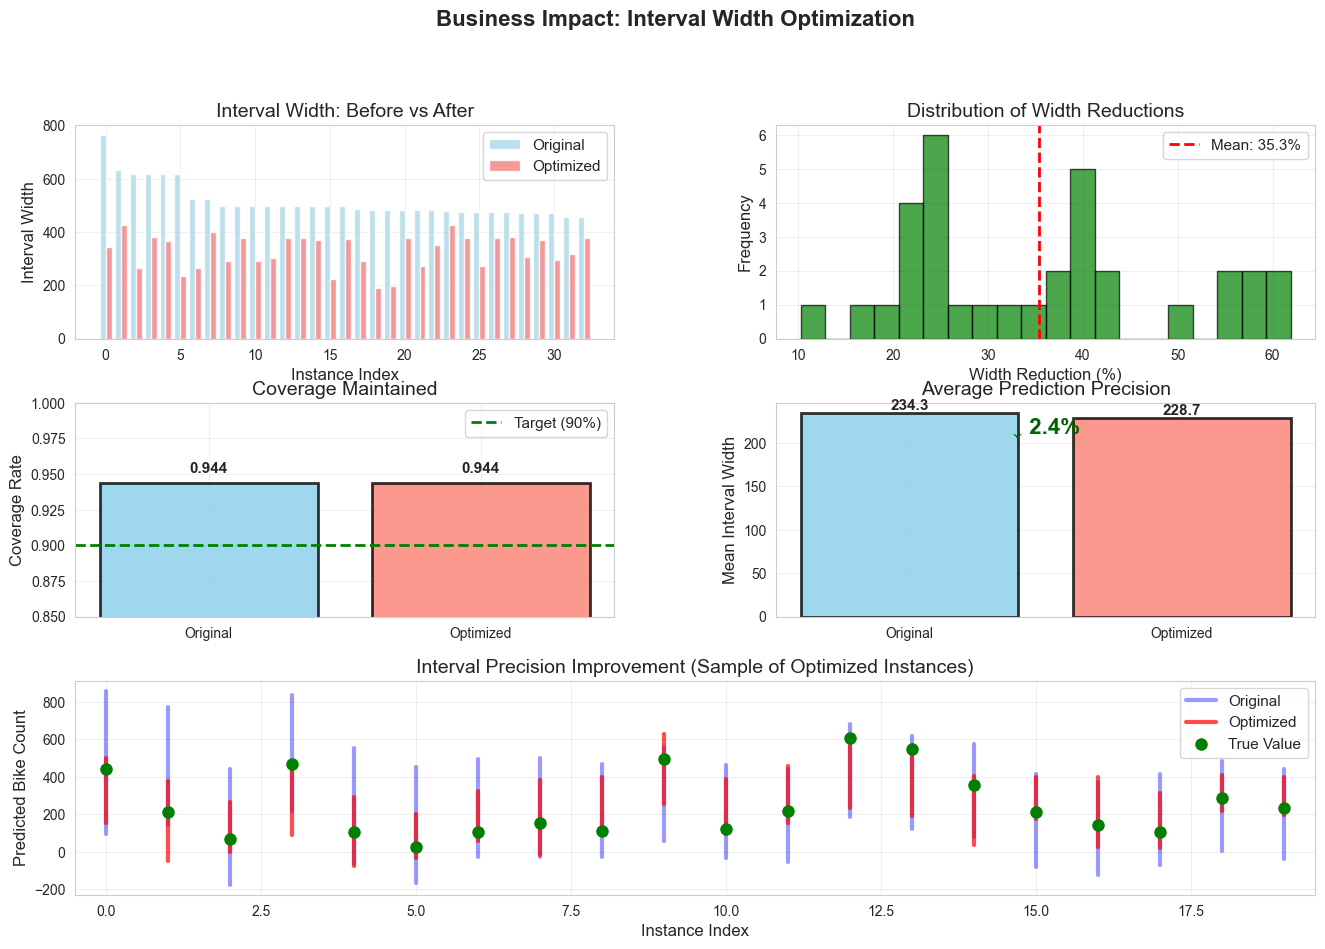


               BUSINESS OPTIMIZATION REPORT

📊 EXECUTIVE SUMMARY
----------------------------------------------------------------------
  • Optimized Predictions: 33 instances
  • Coverage Maintained: 94.39% (target: ≥94.39%)
  • Precision Gain: 2.4% narrower intervals

💡 BUSINESS VALUE
----------------------------------------------------------------------
  • Average Precision Improvement: 35.3%
  • Best Case Improvement: 61.9%
  • Original Mean Width: 234.3 bikes
  • Optimized Mean Width: 228.7 bikes
  • Absolute Reduction: 5.7 bikes

🎯 PRACTICAL APPLICATIONS
----------------------------------------------------------------------
  1. Resource Planning: More accurate bike inventory requirements
  2. Cost Reduction: Minimize over-provisioning by ~2%
  3. Service Quality: Better capacity predictions reduce stockouts
  4. Decision Making: Tighter bounds enable confident operational choices

📈 RECOMMENDATIONS
----------------------------------------------------------------------
  • Depl

In [15]:
# Visualize business impact
plot_business_impact(batch_results)
create_business_report(batch_results)


# ## Feature Importance for Optimization


In [16]:
def analyze_optimization_features(batch_results, feature_cols, context_length):
    """Analyze which features were most changed during optimization."""
    opt_data = batch_results['optimized_instances']

    if not opt_data:
        print("No optimization data available")
        return

    base_dim = len(feature_cols)
    all_changes = []

    for d in opt_data:
        idx = d['idx']
        x_orig = X_test_acpi[idx].reshape(context_length, base_dim)
        x_cf = batch_results['X_optimized'][idx].reshape(context_length, base_dim)
        delta = np.abs(x_cf - x_orig)
        # Average across time lags
        feature_changes = np.mean(delta, axis=0)
        all_changes.append(feature_changes)

    # Average across all optimized instances
    mean_changes = np.mean(all_changes, axis=0)

    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart of feature importance
    indices = np.argsort(mean_changes)[::-1]
    colors = plt.cm.RdYlGn_r(mean_changes[indices] / mean_changes.max())

    ax1.barh(range(len(indices)), mean_changes[indices], color=colors)
    ax1.set_yticks(range(len(indices)))
    ax1.set_yticklabels([feature_cols[i] for i in indices], fontsize=10)
    ax1.set_xlabel('Mean Absolute Change', fontsize=12)
    ax1.set_title('Features Modified for Interval Optimization', fontsize=14)
    ax1.grid(True, axis='x', alpha=0.3)

    # Heatmap of changes across instances
    changes_matrix = np.array(all_changes)[:20]  # Show first 20 instances
    sns.heatmap(changes_matrix.T, ax=ax2, cmap='YlOrRd',
                yticklabels=feature_cols, cbar_kws={'label': 'Absolute Change'})
    ax2.set_xlabel('Instance Index', fontsize=12)
    ax2.set_ylabel('Feature', fontsize=12)
    ax2.set_title('Feature Changes Across Optimized Instances', fontsize=14)

    plt.tight_layout()
    plt.show()

    # Print top features
    print("\n🔧 TOP FEATURES MODIFIED FOR OPTIMIZATION:")
    print("-" * 60)
    for i, idx in enumerate(indices[:10]):
        print(f"  {i+1}. {feature_cols[idx]:20s} → Avg change: {mean_changes[idx]:.4f}")


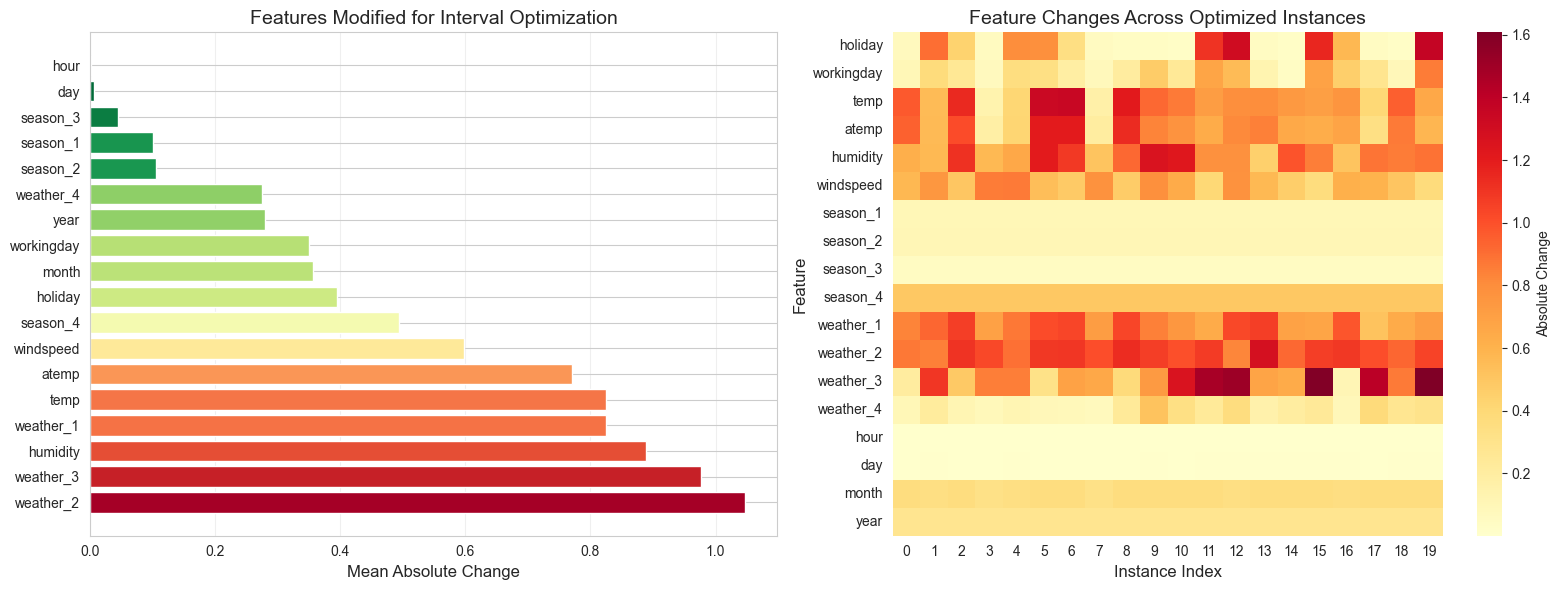


🔧 TOP FEATURES MODIFIED FOR OPTIMIZATION:
------------------------------------------------------------
  1. weather_2            → Avg change: 1.0462
  2. weather_3            → Avg change: 0.9760
  3. humidity             → Avg change: 0.8882
  4. weather_1            → Avg change: 0.8256
  5. temp                 → Avg change: 0.8243
  6. atemp                → Avg change: 0.7706
  7. windspeed            → Avg change: 0.5980
  8. season_4             → Avg change: 0.4932
  9. holiday              → Avg change: 0.3954
  10. month                → Avg change: 0.3563


In [17]:
# Analyze which features drove the optimization
analyze_optimization_features(batch_results, feature_cols, context_length)


# ## Actionable Insights Extraction


In [18]:
def extract_actionable_insights(batch_results, feature_cols, context_length, top_n=5):
    """
    Extract actionable business insights from the optimization.
    Show what specific operational changes lead to better predictions.
    """
    opt_data = batch_results['optimized_instances']

    if not opt_data:
        print("No optimization data available")
        return

    print("\n" + "="*70)
    print(" " * 20 + "ACTIONABLE INSIGHTS")
    print("="*70)

    base_dim = len(feature_cols)

    # Analyze top performing optimizations
    sorted_opt = sorted(opt_data, key=lambda x: x['reduction_pct'], reverse=True)[:top_n]

    for rank, opt in enumerate(sorted_opt, 1):
        idx = opt['idx']
        x_orig = X_test_acpi[idx].reshape(context_length, base_dim)
        x_cf = batch_results['X_optimized'][idx].reshape(context_length, base_dim)

        print(f"\n📍 INSIGHT #{rank} (Instance {idx})")
        print(f"   Interval reduced by {opt['reduction_pct']:.1f}%: " +
              f"[{opt['original_lower']:.1f}, {opt['original_upper']:.1f}] → " +
              f"[{opt['new_lower']:.1f}, {opt['new_upper']:.1f}]")
        print(f"   True demand: {opt['y_true']:.1f} bikes")
        print()

        # Find most changed features
        delta = x_cf - x_orig
        avg_delta_per_feature = np.mean(delta, axis=0)

        # Get top 3 most changed features
        abs_changes = np.abs(avg_delta_per_feature)
        top_features_idx = np.argsort(abs_changes)[-3:][::-1]

        print("   🔧 Key Operational Changes:")
        for feat_idx in top_features_idx:
            feat_name = feature_cols[feat_idx]
            change = avg_delta_per_feature[feat_idx]
            direction = "↑" if change > 0 else "↓"

            # Provide business interpretation
            interpretation = get_feature_interpretation(feat_name, change)
            print(f"      • {feat_name}: {direction} {abs(change):.3f}")
            print(f"        → {interpretation}")

        print()

def get_feature_interpretation(feature_name, change):
    """Provide business interpretation for feature changes."""
    direction = "increase" if change > 0 else "decrease"

    interpretations = {
        'temp': f"Temperature conditions {direction} → affects comfort and ridership",
        'humidity': f"Humidity {direction} → impacts weather appeal",
        'windspeed': f"Wind conditions {direction} → changes riding difficulty",
        'weather_clear': f"Clear weather probability {direction}",
        'weather_cloudy': f"Cloudy conditions {direction}",
        'weather_rain': f"Rain likelihood {direction}",
        'holiday': f"Holiday status {direction}",
        'workingday': f"Working day classification {direction}",
    }

    # Check for partial matches
    for key, value in interpretations.items():
        if key in feature_name.lower():
            return value

    return f"{direction.capitalize()} in {feature_name} impacts prediction precision"


In [19]:
# Extract actionable insights
extract_actionable_insights(batch_results, feature_cols, context_length, top_n=5)



                    ACTIONABLE INSIGHTS

📍 INSIGHT #1 (Instance 830)
   Interval reduced by 61.9%: [-165.8, 452.4] → [-33.8, 201.7]
   True demand: 23.0 bikes

   🔧 Key Operational Changes:
      • temp: ↑ 1.338
        → Temperature conditions increase → affects comfort and ridership
      • humidity: ↓ 1.202
        → Humidity decrease → impacts weather appeal
      • atemp: ↑ 1.201
        → Temperature conditions increase → affects comfort and ridership


📍 INSIGHT #2 (Instance 1052)
   Interval reduced by 60.8%: [2.8, 484.2] → [218.7, 407.3]
   True demand: 286.0 bikes

   🔧 Key Operational Changes:
      • temp: ↑ 0.949
        → Temperature conditions increase → affects comfort and ridership
      • atemp: ↑ 0.865
        → Temperature conditions increase → affects comfort and ridership
      • humidity: ↓ 0.805
        → Humidity decrease → impacts weather appeal


📍 INSIGHT #3 (Instance 862)
   Interval reduced by 58.7%: [-38.5, 442.9] → [198.0, 397.0]
   True demand: 236.0 b

# ## Compare Original vs Optimized Dataset


In [20]:
def compare_datasets(X_original, X_optimized, y_true, acpi_model):
    """Comprehensive comparison of original vs optimized datasets."""

    # Get predictions for both
    lower_orig, upper_orig = acpi_model.predict_pi(X_original, method='qrf')
    lower_opt, upper_opt = acpi_model.predict_pi(X_optimized, method='qrf')

    # Calculate metrics
    widths_orig = upper_orig - lower_orig
    widths_opt = upper_opt - lower_opt

    coverage_orig = np.mean((y_true >= lower_orig) & (y_true <= upper_orig))
    coverage_opt = np.mean((y_true >= lower_opt) & (y_true <= upper_opt))

    # Create comparison visualization
    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

    # 1. Width distributions
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.hist(widths_orig, bins=50, alpha=0.6, label='Original', color='blue', edgecolor='black')
    ax1.hist(widths_opt, bins=50, alpha=0.6, label='Optimized', color='red', edgecolor='black')
    ax1.axvline(np.mean(widths_orig), color='blue', linestyle='--', linewidth=2,
                label=f'Orig Mean: {np.mean(widths_orig):.1f}')
    ax1.axvline(np.mean(widths_opt), color='red', linestyle='--', linewidth=2,
                label=f'Opt Mean: {np.mean(widths_opt):.1f}')
    ax1.set_xlabel('Interval Width', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Distribution of Interval Widths', fontsize=14)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # 2. Coverage comparison
    ax2 = fig.add_subplot(gs[0, 1])
    categories = ['Original', 'Optimized']
    coverages = [coverage_orig, coverage_opt]
    colors_cov = ['skyblue', 'lightcoral']
    bars = ax2.bar(categories, coverages, color=colors_cov, edgecolor='black', linewidth=2, alpha=0.8)
    ax2.axhline(0.9, color='green', linestyle='--', linewidth=2, label='90% Target')
    ax2.set_ylabel('Coverage Rate', fontsize=12)
    ax2.set_title('Prediction Coverage', fontsize=14)
    ax2.set_ylim([0.85, 1.0])
    ax2.legend(fontsize=10)
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                f'{height:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax2.grid(True, alpha=0.3)

    # 3. Efficiency gain
    ax3 = fig.add_subplot(gs[0, 2])
    efficiency_orig = 1 / widths_orig  # Inverse of width = precision
    efficiency_opt = 1 / widths_opt

    ax3.scatter(efficiency_orig, efficiency_opt, alpha=0.5, s=30)
    max_eff = max(efficiency_orig.max(), efficiency_opt.max())
    ax3.plot([0, max_eff], [0, max_eff], 'r--', linewidth=2, label='No Change')
    ax3.set_xlabel('Original Efficiency (1/width)', fontsize=12)
    ax3.set_ylabel('Optimized Efficiency (1/width)', fontsize=12)
    ax3.set_title('Prediction Efficiency Gain', fontsize=14)
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

    # 4. Width reduction by instance
    ax4 = fig.add_subplot(gs[1, :])
    width_changes = widths_opt - widths_orig
    improved_mask = width_changes < 0

    x_improved = np.where(improved_mask)[0]
    x_same = np.where(~improved_mask)[0]

    ax4.scatter(x_improved, width_changes[improved_mask],
                c='green', alpha=0.6, s=20, label=f'Improved ({np.sum(improved_mask)} instances)')
    ax4.scatter(x_same, width_changes[x_same],
                c='gray', alpha=0.3, s=20, label=f'Unchanged ({np.sum(~improved_mask)} instances)')
    ax4.axhline(0, color='black', linestyle='-', linewidth=1)
    ax4.set_xlabel('Instance Index', fontsize=12)
    ax4.set_ylabel('Width Change (Optimized - Original)', fontsize=12)
    ax4.set_title('Per-Instance Interval Width Changes', fontsize=14)
    ax4.legend(fontsize=11)
    ax4.grid(True, alpha=0.3)

    plt.suptitle('Comprehensive Dataset Comparison: Original vs Optimized',
                 fontsize=16, fontweight='bold', y=0.995)
    plt.show()

    # Print summary statistics
    print("\n" + "="*70)
    print(" " * 20 + "DATASET COMPARISON SUMMARY")
    print("="*70)
    print(f"\n📊 Coverage:")
    print(f"   Original:  {coverage_orig:.4f} ({coverage_orig*100:.2f}%)")
    print(f"   Optimized: {coverage_opt:.4f} ({coverage_opt*100:.2f}%)")
    print(f"   Change:    {coverage_opt - coverage_orig:+.4f}")

    print(f"\n📏 Interval Width:")
    print(f"   Original Mean:    {np.mean(widths_orig):.2f}")
    print(f"   Optimized Mean:   {np.mean(widths_opt):.2f}")
    print(f"   Reduction:        {np.mean(widths_orig) - np.mean(widths_opt):.2f} " +
          f"({(1 - np.mean(widths_opt)/np.mean(widths_orig))*100:.1f}%)")

    print(f"\n✨ Instances Improved: {np.sum(improved_mask)} / {len(y_true)} " +
          f"({np.sum(improved_mask)/len(y_true)*100:.1f}%)")

    print("\n" + "="*70)


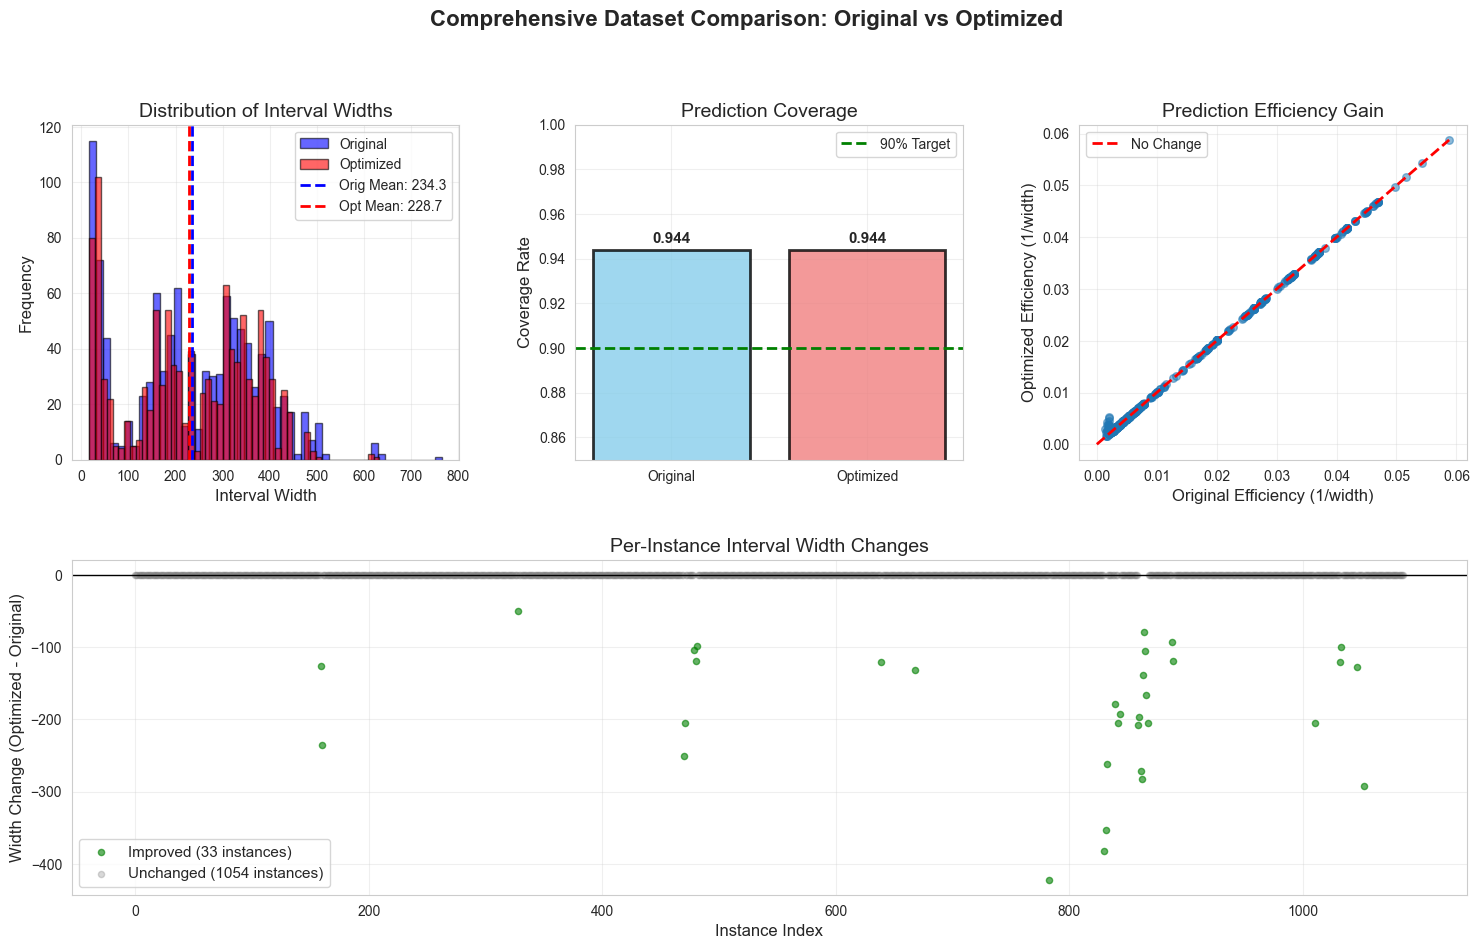


                    DATASET COMPARISON SUMMARY

📊 Coverage:
   Original:  0.9439 (94.39%)
   Optimized: 0.9439 (94.39%)
   Change:    +0.0000

📏 Interval Width:
   Original Mean:    234.30
   Optimized Mean:   228.65
   Reduction:        5.65 (2.4%)

✨ Instances Improved: 33 / 1087 (3.0%)



In [21]:
# Run comprehensive comparison
compare_datasets(X_test_acpi, batch_results['X_optimized'], y_test_acpi, acpi_model)
